In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import pandas as pd
from skimage import measure
from skimage.measure import regionprops, regionprops_table
import math

import sys
sys.path.append('../../src')
from utils import smooth_curve
from PlumeDataset import plume_dataset
from Viz import show_images, create_axes_grid
from PlumeMetrics import PlumeMetrics
from Velocity import VelocityCalculator

<KeysViewHDF5 ['1-BaTiO3', '1-BaTiO3_Pre']>


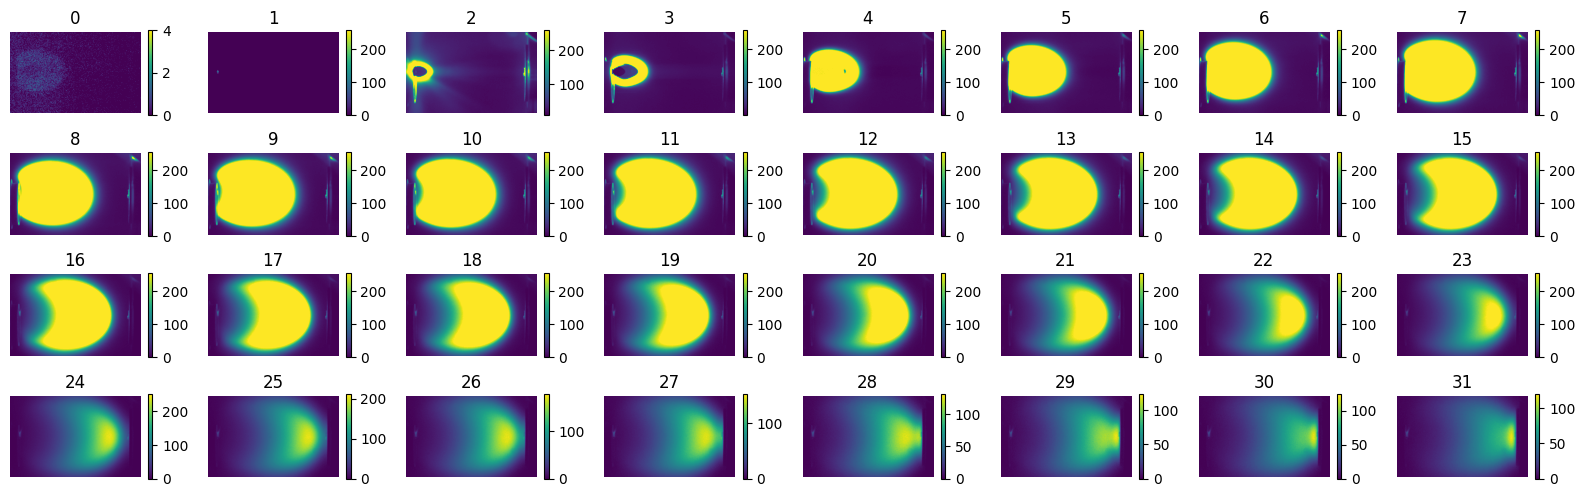

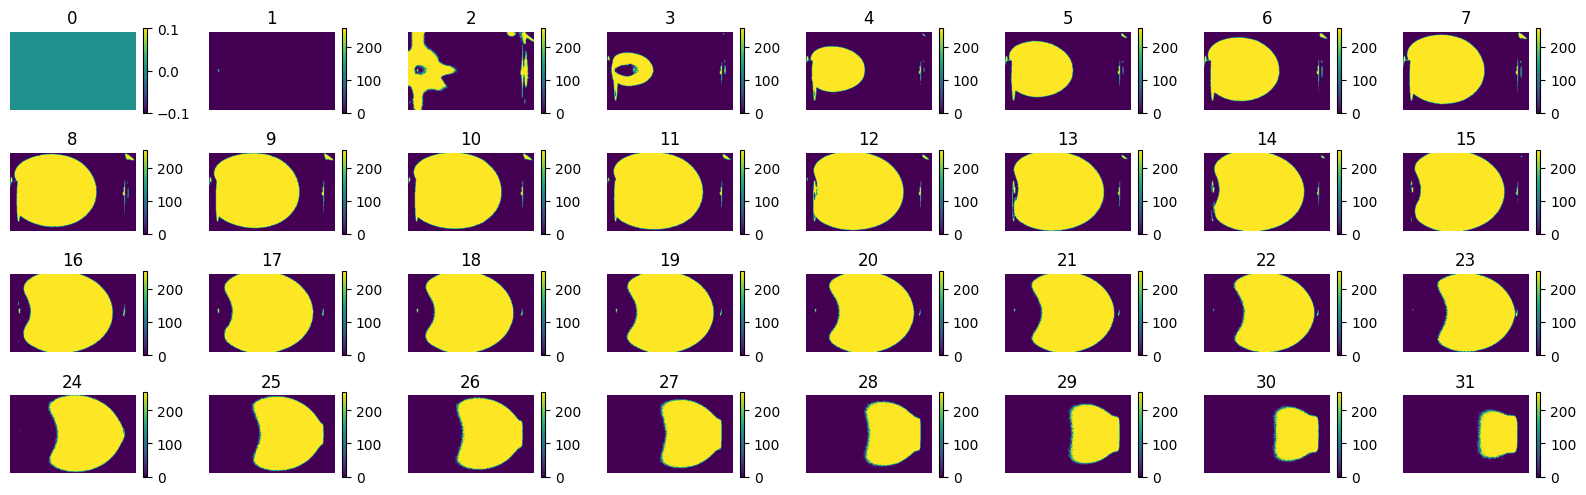

In [2]:
plume_ds = plume_dataset(file_path='../../datasets/LYW152_YichenGuo_JulianGoddy_03072024.h5', group_name='PLD_Plumes')
plume_ds.show_dataset_name()
plumes = plume_ds.load_plumes('1-BaTiO3')

plume = plumes[0][:32]
show_images(plume, img_per_row=8, show_colorbar=True, clim=None)

plume_binary = np.copy(plume)
for i in range(len(plume_binary)):
    _, plume_binary[i] = cv2.threshold(plume_binary[i], 50, 255, cv2.THRESH_BINARY)

show_images(plume_binary, img_per_row=8, show_colorbar=True, clim=None)

In [3]:
position_range = (34, 367) # (x1, x2)
start_position = (29, 126) # (x, y)
threshold = 200
time_interval = 500e-9 # 500ns
P = PlumeMetrics(time_interval, position_range, start_position, threshold=threshold)

In [5]:
areas = np.zeros(plumes.shape[:2])

for i in tqdm(range(plumes.shape[0])):
    for j in range(plumes.shape[1]):
        # print(i, j)
        frame = plumes[i, j]
        areas[i, j] = P.calculate_area(frame, threshold)

100%|██████████| 173/173 [00:04<00:00, 41.89it/s]


                        area_flex
plume_index time_index           
0           0                 0.0
            1                 2.0
            2              3669.0
            3              6536.0
            4             16197.0


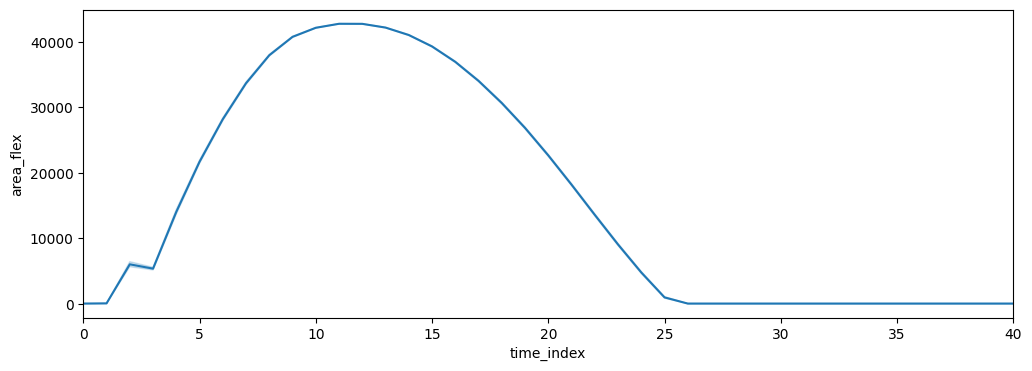

In [ ]:
# Example data
num_plumes = plumes.shape[0]
num_times = plumes.shape[1]

# Create a MultiIndex
plume_indices = np.repeat(np.arange(num_plumes), num_times)
time_indices = np.tile(np.arange(num_times), num_plumes)
multi_index = pd.MultiIndex.from_arrays([plume_indices, time_indices], names=['plume_index', 'time_index'])

# Create the DataFrame
df = pd.DataFrame({
                    'area_flex': areas.flatten() 
                    }, index=multi_index)

print(df.head())

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(x="time_index", y="area_flex", data=df)
plt.xlim(0, 40)
plt.show()

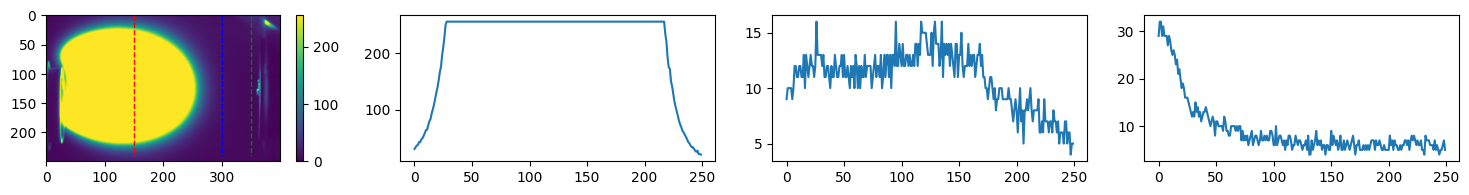

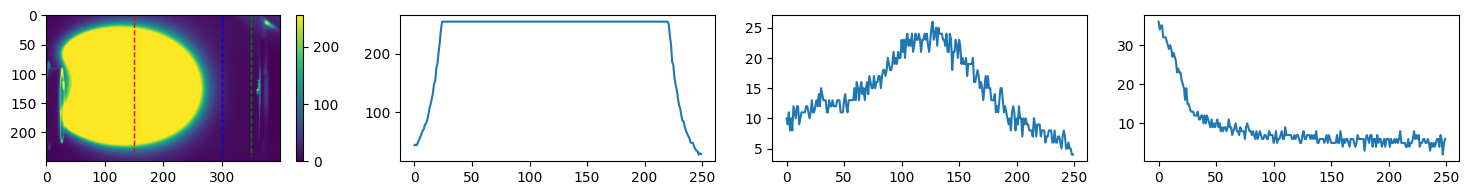

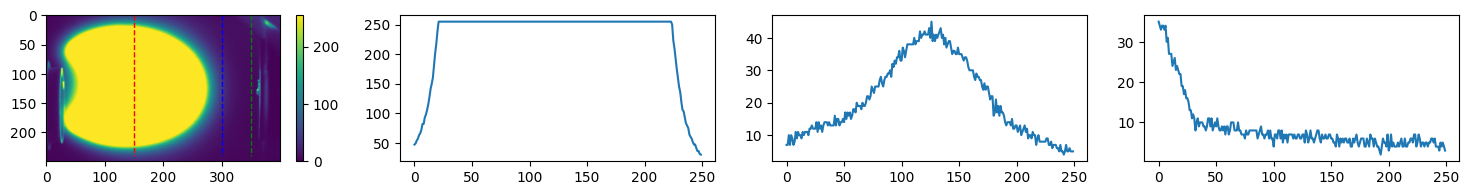

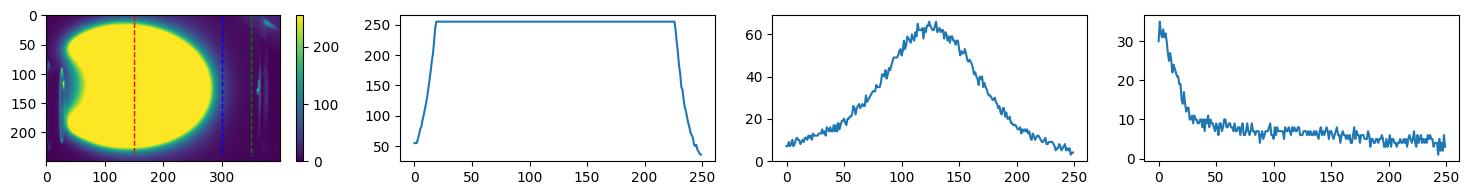

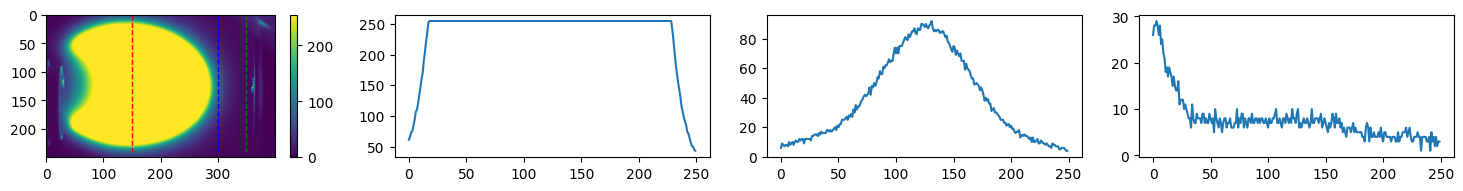

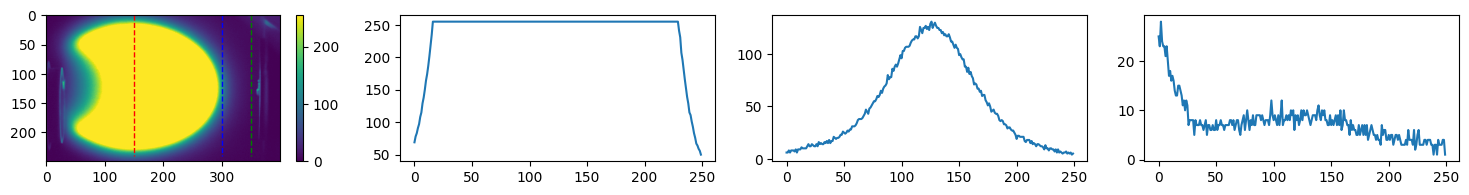

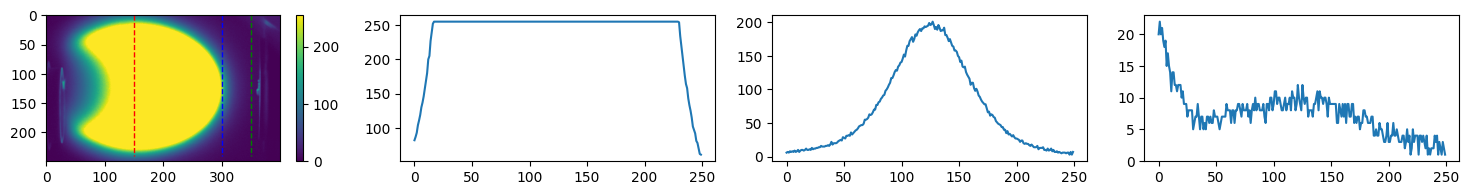

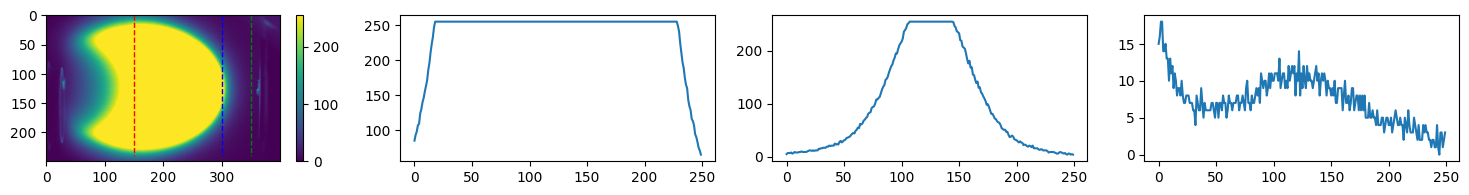

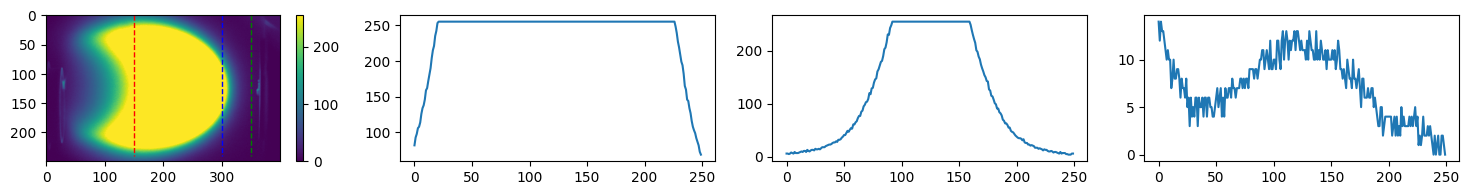

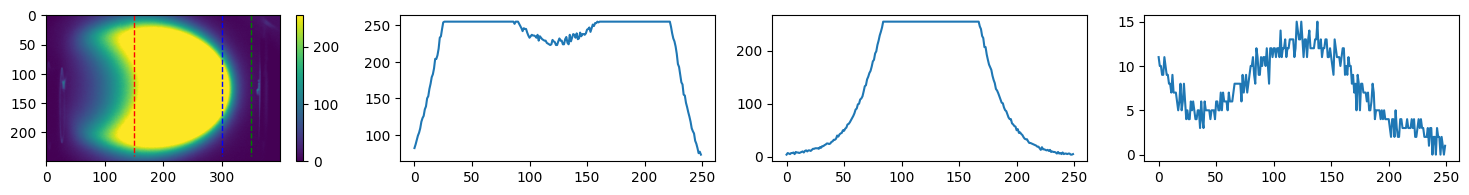

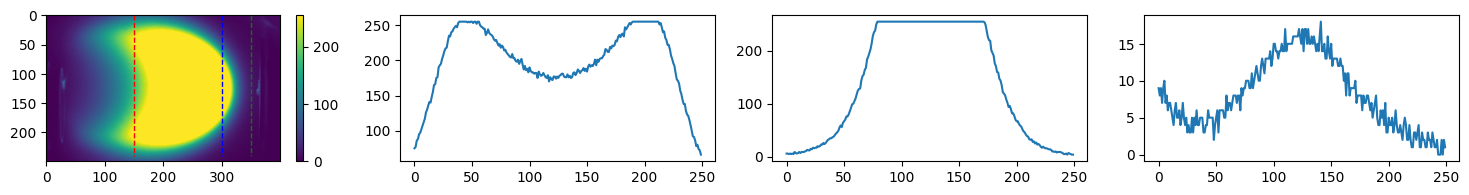

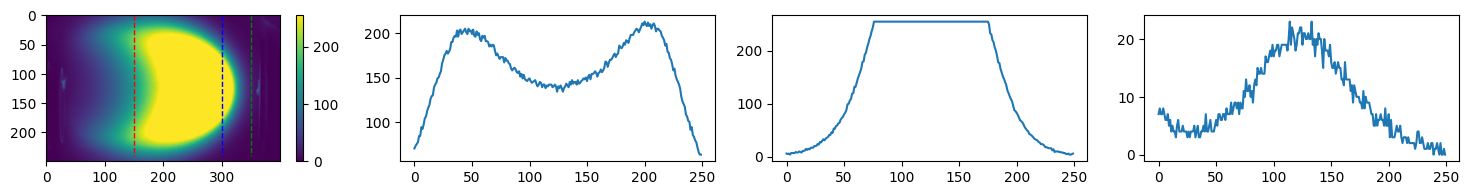

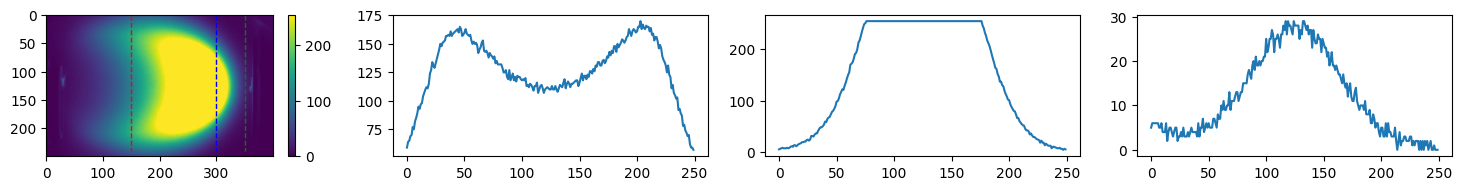

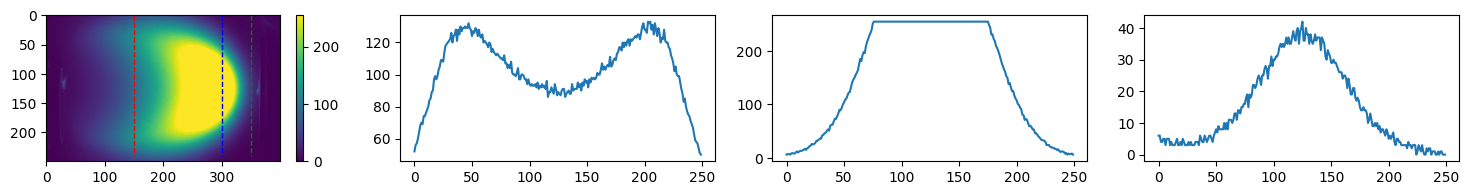

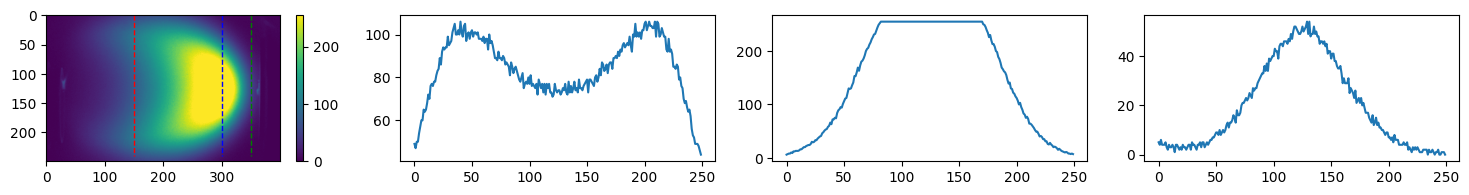

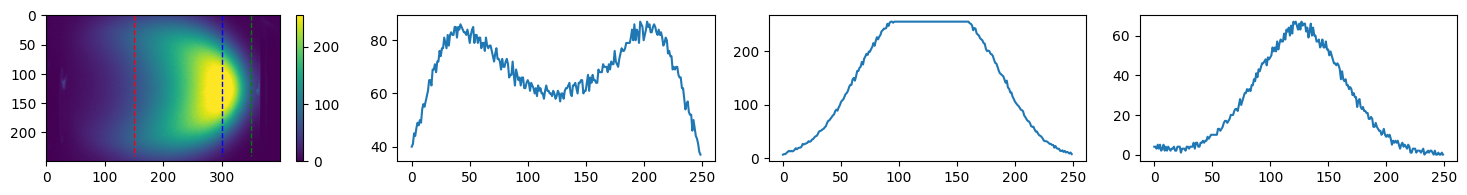

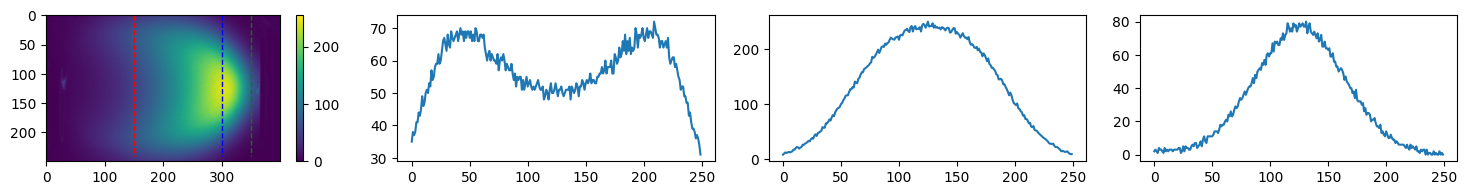

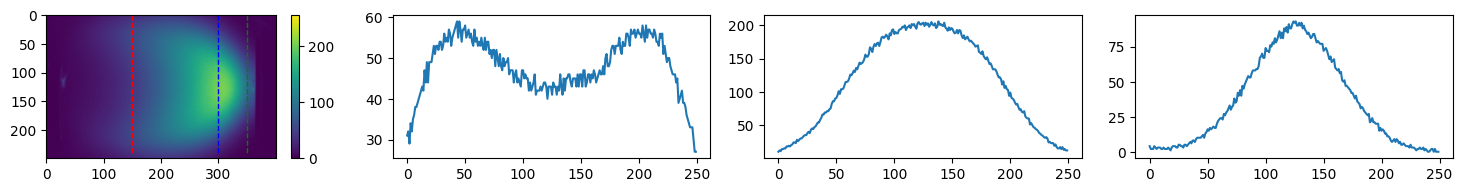

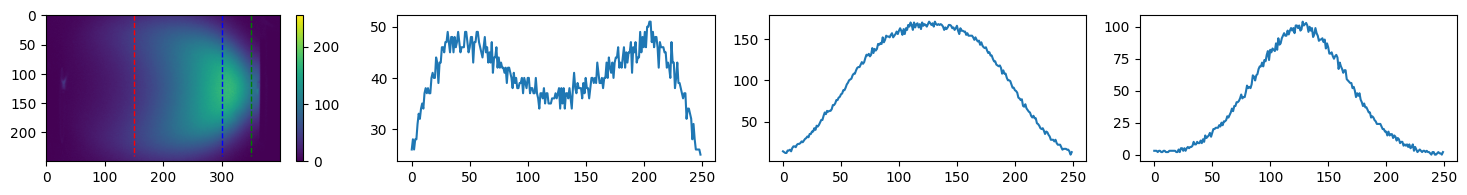

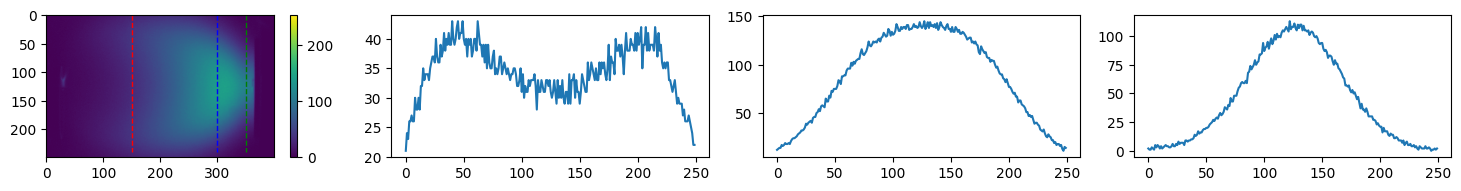

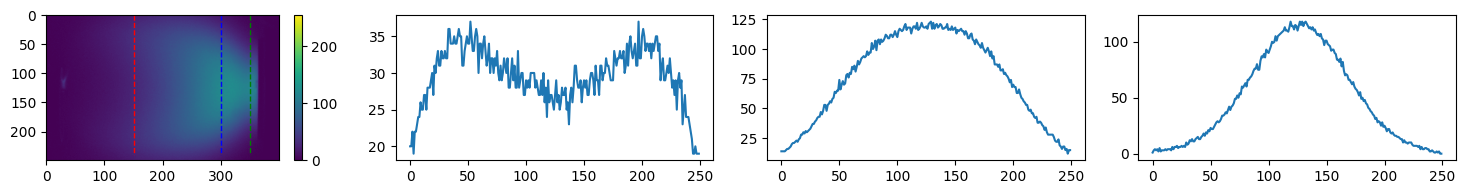

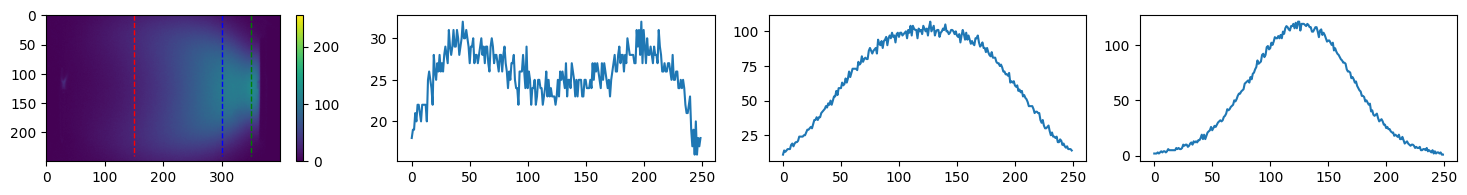

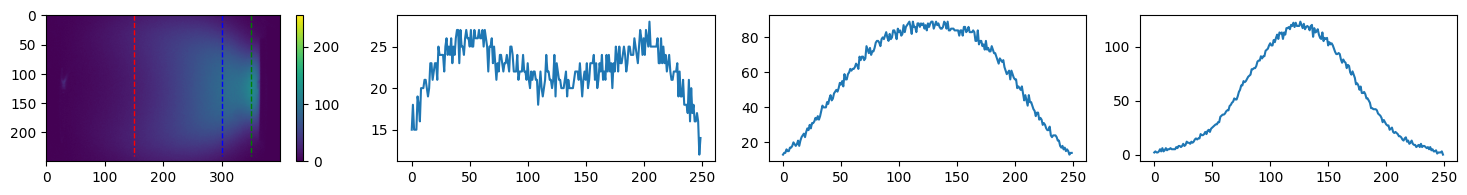

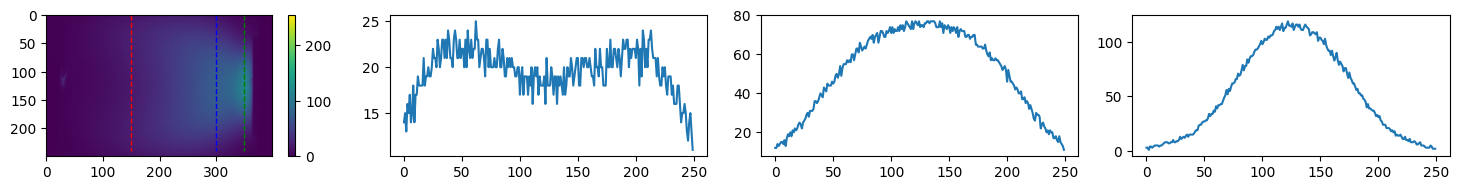

In [184]:
for i in range(8, 32):
    fig, axes = plt.subplots(1, 4, figsize=(15, 2))
    x1, x2, x3 = 150, 300, 350
    im = axes[0].imshow(plumes[0, i])
    axes[0].plot([x1, x1], [0, 240], 'r--', linewidth=1)
    axes[0].plot([x2, x2], [0, 240], 'b--', linewidth=1)
    axes[0].plot([x3, x3], [0, 240], 'g--', linewidth=1)
    im.set_clim(0, 255)
    fig.colorbar(im, ax=axes[0])

    axes[1].plot(plumes[0, i][:, x1])
    axes[2].plot(plumes[0, i][:, x2])
    axes[3].plot(plumes[0, i][:, x3])
    plt.tight_layout()
    plt.show()